# Generalized Integrate-and-Fire Neuron

In [1]:
#!pip install ANNarchy

This notebook explores the generalized Integrate-and-Fire neuron model being used for reproducing measured data.

Code based on:

> Schwalger, T., Deger, M., Gerstner, w. (2017). Towards a theory of cortical columns: From spiking neurons to interacting neural populations of finite size. PLoS Comput Biol. 2017;13(4):e1005507


In [2]:
import matplotlib.pyplot as plt
import numpy

import ANNarchy as ann

ANNarchy 5.1 (5.1.0b) on linux (posix).


The generalized Integrate-and-Fire (GIF) neuron is defined by the following equations:

$$
    \tau_m \frac{du}{dt} = -u + u_r + R*I_{ext}
$$

$$
    \tau_v \frac{dv}{dt} = -(v-u_{th})
$$

Spike emission is the result of a stochastic process, where the threshold $\lambda$, also called hazard-rate, follows the difference between the membrane potential $u$ and an adaptive threshold $v$:

$$
    \lambda = c * exp(\frac{u-v}{\delta_{u}})
$$

This could be implemented in ANNarchy like the following. Note that we split the pre-synaptic inputs (*syn*) into excitatory (*exc*) and inhibitory (*inh*). We also added an exponential decay on the inputs, with the time constants $\tau_{g_{exc}}$ and $\tau_{g_{inh}}$.

In [3]:
GIF = ann.Neuron(
    # Values are taken from Schwalger et al. (2017), Table 1
    parameters=dict(
        tau_m       =   10.0,
        tau_v       = 1000.0,
        J_v         = 1000.0,
        u_r         =   25.0,
        u_th        =   10.0,
        R           =   0.04, # R = tau_m / C = 10ms / 250 pA
        c           =   10.0,
        delta_u     =    5.0,
        I_ext       =    0.0
    ),
    equations=[
        # membrane potential
        ann.Variable("tau_m * du/dt = -u + u_r + R*I_ext", init=10.0),
        ann.Variable("mu = u_r + R * I_ext"), # for recording
        # adaptive spike threshold, v is incremented by each spike, otherwise decays toward u_t
        ann.Variable("tau_v * dv/dt = -(v-u_th)", init='u_th'),
        # escape rate in Hz, resp. spikes/s
        ann.Variable("Lambda = c * exp((u-v)/delta_u)"),
        # Note: we need to map from ms -> s, that it fits to rate in Hz
        ann.Variable("p = Uniform(0.0, 1.0) * 1000.0 / dt"),
        # external input
    ],
    spike = "p < Lambda",
    reset = """
        u = u_r
        v += J_v/tau_v
    """
)

In [4]:
net = ann.Network()

P = net.create(500, neuron=GIF)

# select only one neuron
m = net.monitor(P[15], ["Lambda", "p", "mu", "u", "v", "spike"])

# record spikes of all neurons
m2 = net.monitor(P, "spike")

net.compile()

# -> mu = 15 mv
P.I_ext = (15 - P.u_r)/P.R
net.simulate(300)

# -> mu = 30 mv
P.I_ext = (30 - P.u_r)/P.R
net.simulate(300)

[CALL]    ConnectivityModule::init_rng(this=nullptr)
[ARGS]    - seed: 438516428
[CALL]    ConnectivityModule::init_rng(this=nullptr)
[ARGS]    - seed: 1574207618


Text(0.5, 0, 'biological time [ms]')

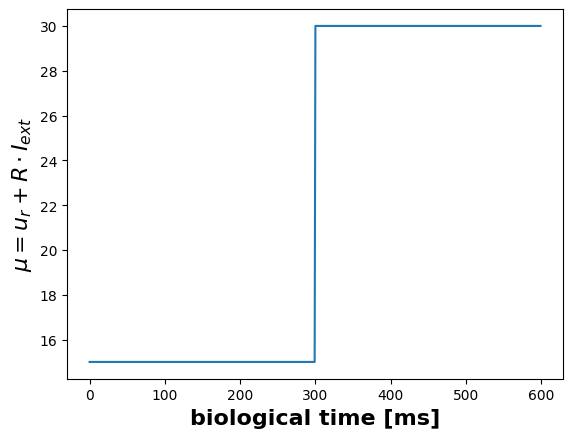

In [5]:
plt.figure()
plt.plot(m.get("mu"))
plt.ylabel(r"$\mu = u_r + R \cdot I_{ext}$", fontsize=16, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=16, fontweight="bold")

Text(0.5, 0, 'biological time [ms]')

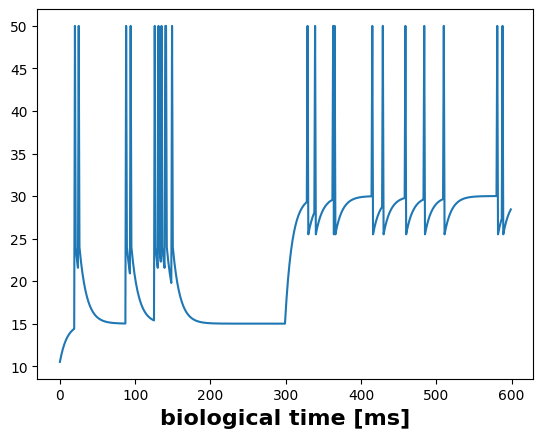

In [6]:
plt.figure()
u_data = m.get("u")
spikes = m.get("spike")[15]
u_data[spikes] = 50   # arbitrary value to highlight the spike
plt.plot(u_data)
plt.xlabel("membrane potential [mV]", fontsize=16, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=16, fontweight="bold")

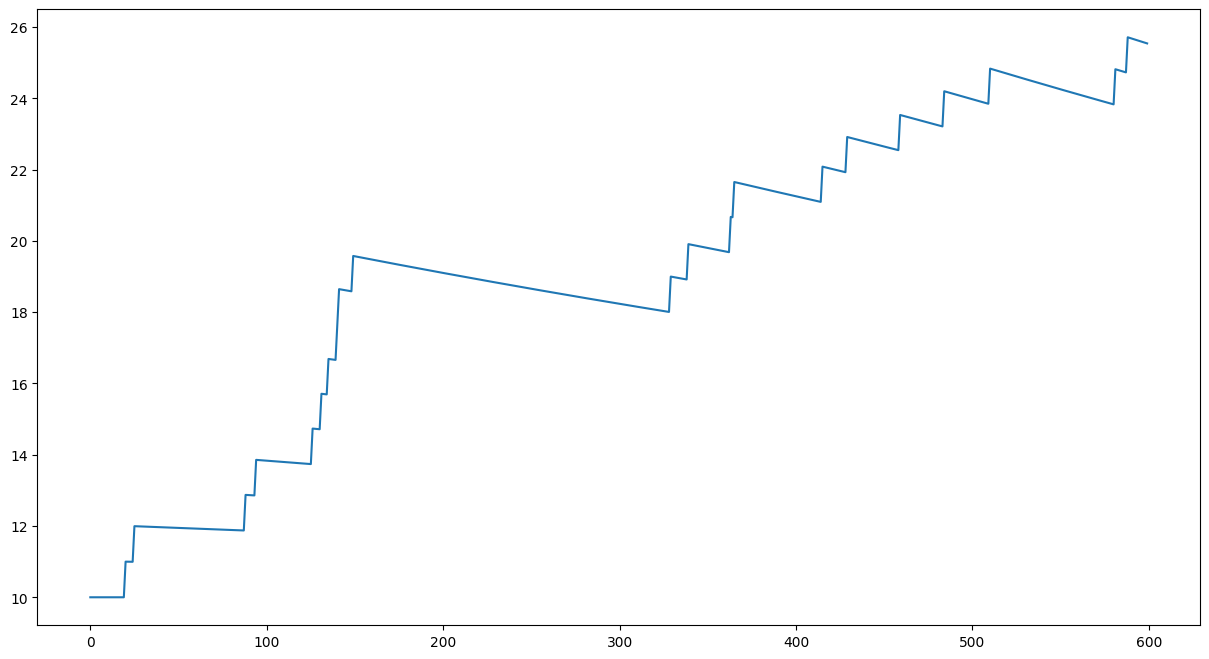

In [7]:
plt.figure(figsize=(15, 8))
v_data = m.get("v")
plt.plot(v_data)

AttributeError: 'Network' object has no attribute 'm'

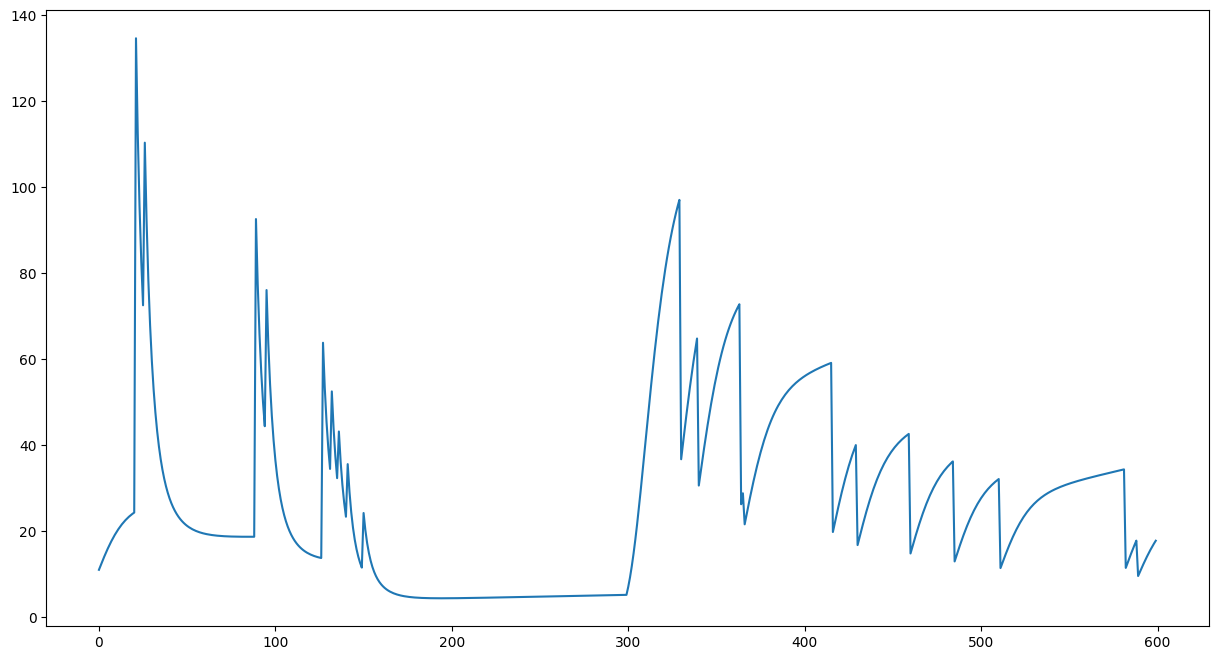

In [8]:
plt.figure(figsize=(15, 8))
lamda_data = m.get("Lambda")
plt.plot(lamda_data)

p_data = m.get("p")
plt.plot(p_data)

In [ ]:
spikes = m2.get("spike")

In [ ]:
plt.figure(figsize=(15, 8))
t, n = m2.raster_plot(spikes)
plt.plot(t, n, "b.")


In [ ]:
fr = m2.histogram(spikes)
plt.plot(fr)

print(numpy.mean(fr[:300]))
print(numpy.mean(fr[300:]))

In [ ]:
smooth_fr = m2.smoothed_rate(spikes, 1.0) # 1ms window
plt.plot(numpy.mean(smooth_fr, axis=0))